In [83]:
# Basic core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [85]:
#libraries for visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [87]:
#libraries for the KNN algorithm
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
roc_auc_score, roc_curve, ConfusionMatrixDisplay)

In [89]:
#Plot Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

print('Libraries Loaded Successfully')

Libraries Loaded Successfully


In [91]:
# To load the dataset
df = pd.read_csv('wine.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
df.head()

Dataset Shape: (1599, 12)

Column Names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


In [93]:
# Basic Information
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   str    
dtypes: float64(11), str(1)
memory usage: 155.6 KB


In [95]:
#To display Statistical Summary
print("Descriptive Statistics")
df.describe().round(3) # 3 decimal places

Descriptive Statistics


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900


In [97]:
#Target Variable
print("Target Class Distribution")
print(df['quality'].value_counts())
print(f"\nClass Ratio (Good:Bad): {df['quality'].value_counts()['good'] / df['quality'].value_counts()['bad']:.2f}:1")

Target Class Distribution
quality
good    855
bad     744
Name: count, dtype: int64

Class Ratio (Good:Bad): 1.15:1


In [99]:
#To find the Missing Values
print("Missing Values")

missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("No missing values found!")
else:
    print(missing[missing > 0])
    print(f"\nTotal missing values: {total_missing}")

Missing Values
No missing values found!


In [109]:
#To check the duplicate value
dupes = df.duplicated().sum()
print(f"Duplicate Rows found: {dupes}")
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")
df.to_csv("cleaned_dataset.csv", index=False)

Duplicate Rows found: 0
Dataset shape after removing duplicates: (1359, 12)


In [121]:
#To find the outliers and treat using IQR clipping
features = df.select_dtypes(include='number').columns.tolist()

outlier_counts = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = count

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index',columns=['Outlier Count'])
outlier_df['% of Data'] = (outlier_df['Outlier Count'] / len(df) * 100).round(1)
print("Outlier Summary (IQR method):")
print(outlier_df.sort_values('Outlier Count',ascending = False))

Outlier Summary (IQR method):
                      Outlier Count  % of Data
residual sugar                  126        9.3
chlorides                        87        6.4
sulphates                        55        4.0
total sulfur dioxide             45        3.3
fixed acidity                    41        3.0
density                          35        2.6
pH                               28        2.1
free sulfur dioxide              26        1.9
volatile acidity                 19        1.4
alcohol                          12        0.9
citric acid                       1        0.1


In [123]:
#Apply IQR 
df_clean = df.copy()
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(lower = Q1 - 1.5*IQR, upper = Q3 + 1.5*IQR)
print(f"Outliers capped using IQR method")
print(f"Shape after cleaning: {df_clean.shape}")

Outliers capped using IQR method
Shape after cleaning: (1359, 12)


In [129]:
#Encoding the Categorical to "0's & 1's"
le = LabelEncoder()
df_clean['quality_encoded'] = le.fit_transform(df_clean['quality'])
print(f"Label Encoding:{dict(zip(le.classes_,le.transform(le.classes_)))}")

Label Encoding:{'bad': np.int64(0), 'good': np.int64(1)}


In [131]:
#To train & test split
x = df_clean[features]
y = df_clean['quality_encoded']

#Train-Test= 80/20
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [135]:
#To feature Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Training Set: {x_train_scaled.shape}")
print(f"Test Set: {x_test_scaled.shape}")
print("Features Standarized (mean=0, std=1)")

Training Set: (1087, 11)
Test Set: (272, 11)
Features Standarized (mean=0, std=1)


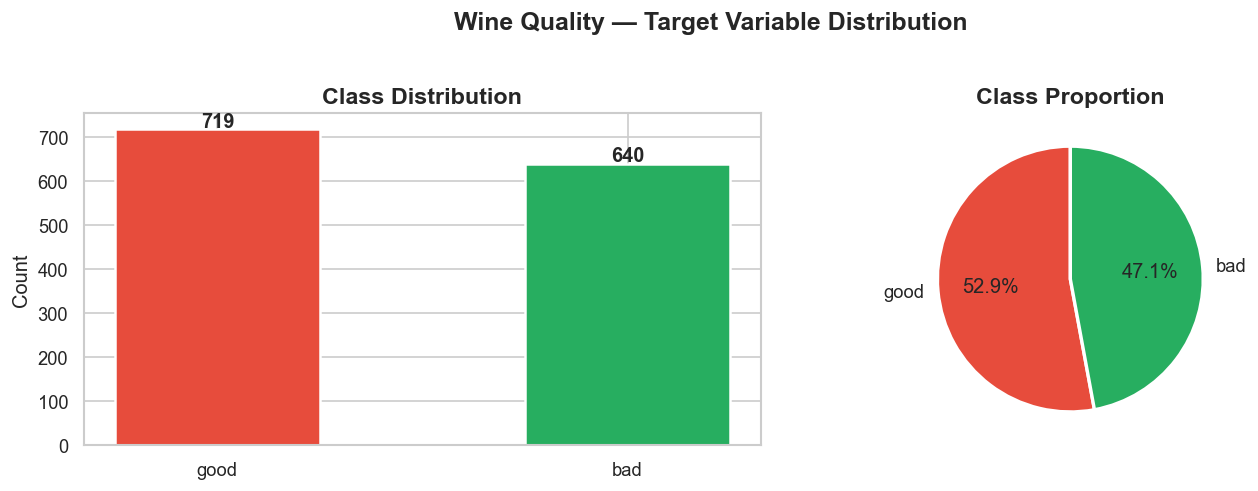

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df_clean['quality'].value_counts()
colors = ['#E74C3C', '#27AE60']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Wine Quality — Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

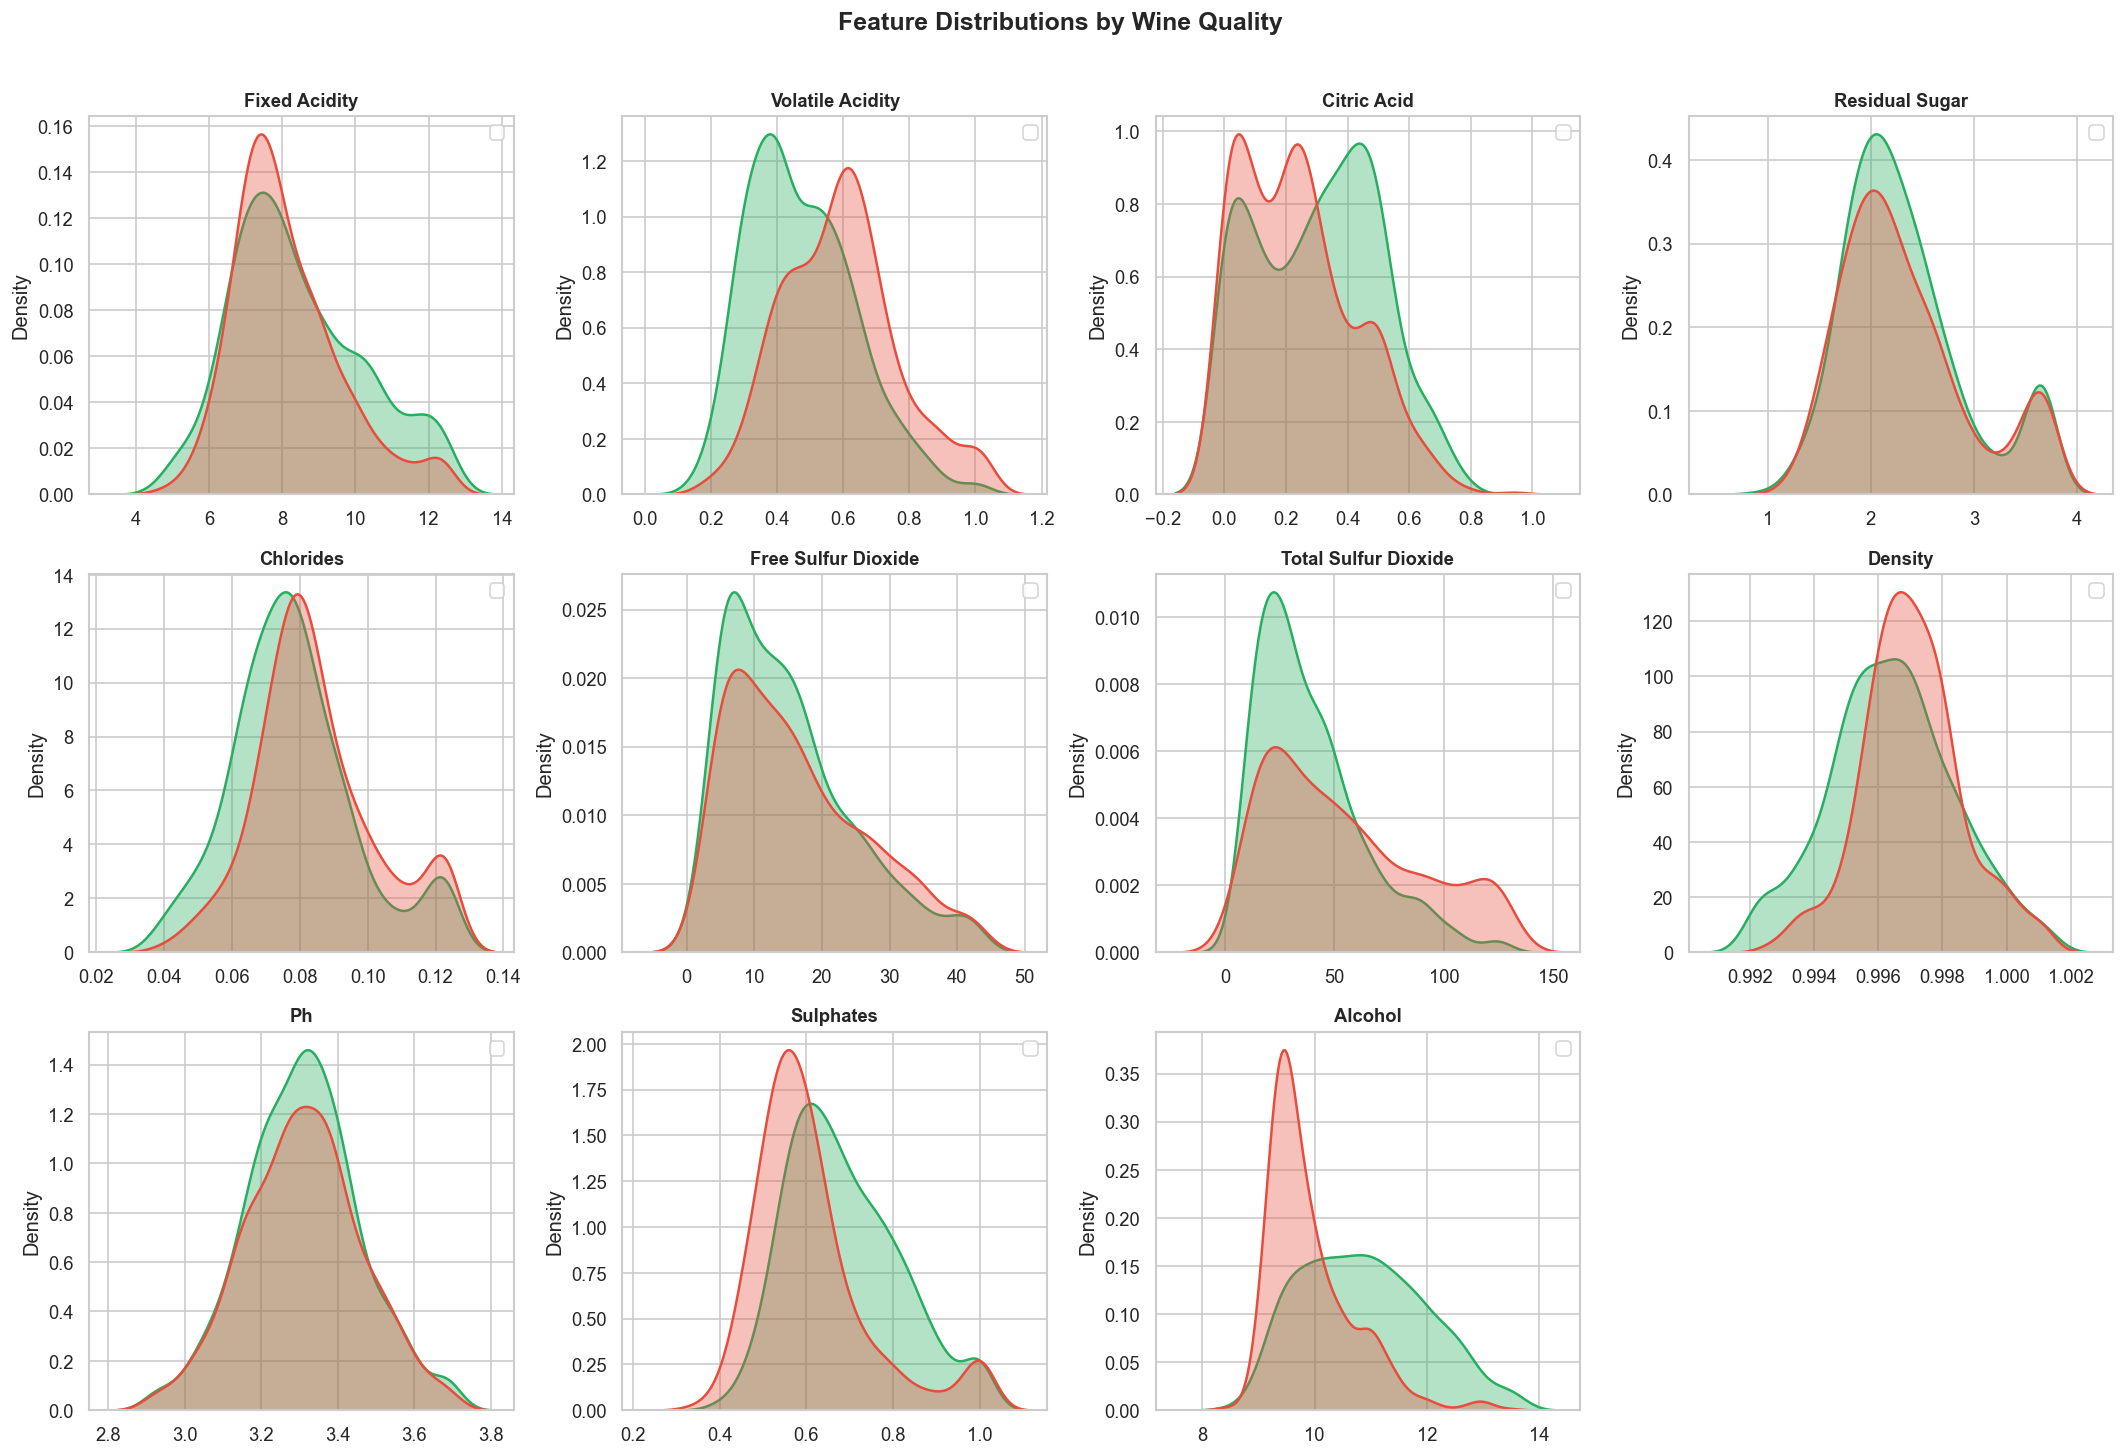

In [155]:
#Feature distributions by quality class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

palette = {'bad': '#E74C3C', 'good': '#27AE60'}
for i, col in enumerate(features):
    sns.kdeplot(data=df_clean, x=col, hue='quality', palette=palette,
                fill=True, alpha=0.35, ax=axes[i], linewidth=1.5)
    axes[i].set_title(col.title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions by Wine Quality', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

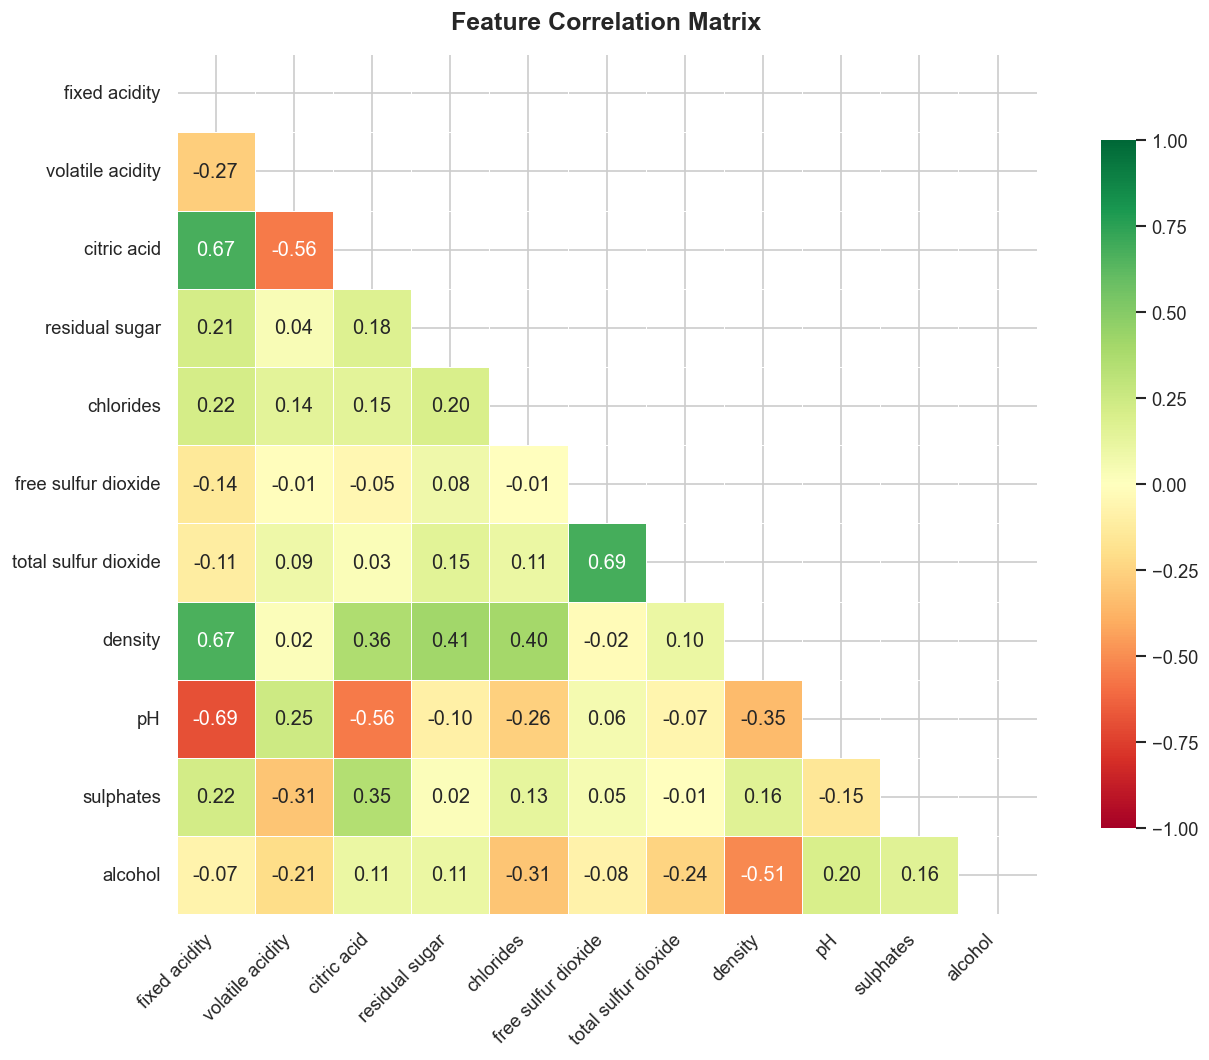

In [159]:
#Correlation heatmap
plt.figure(figsize=(12, 9))
corr = x.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

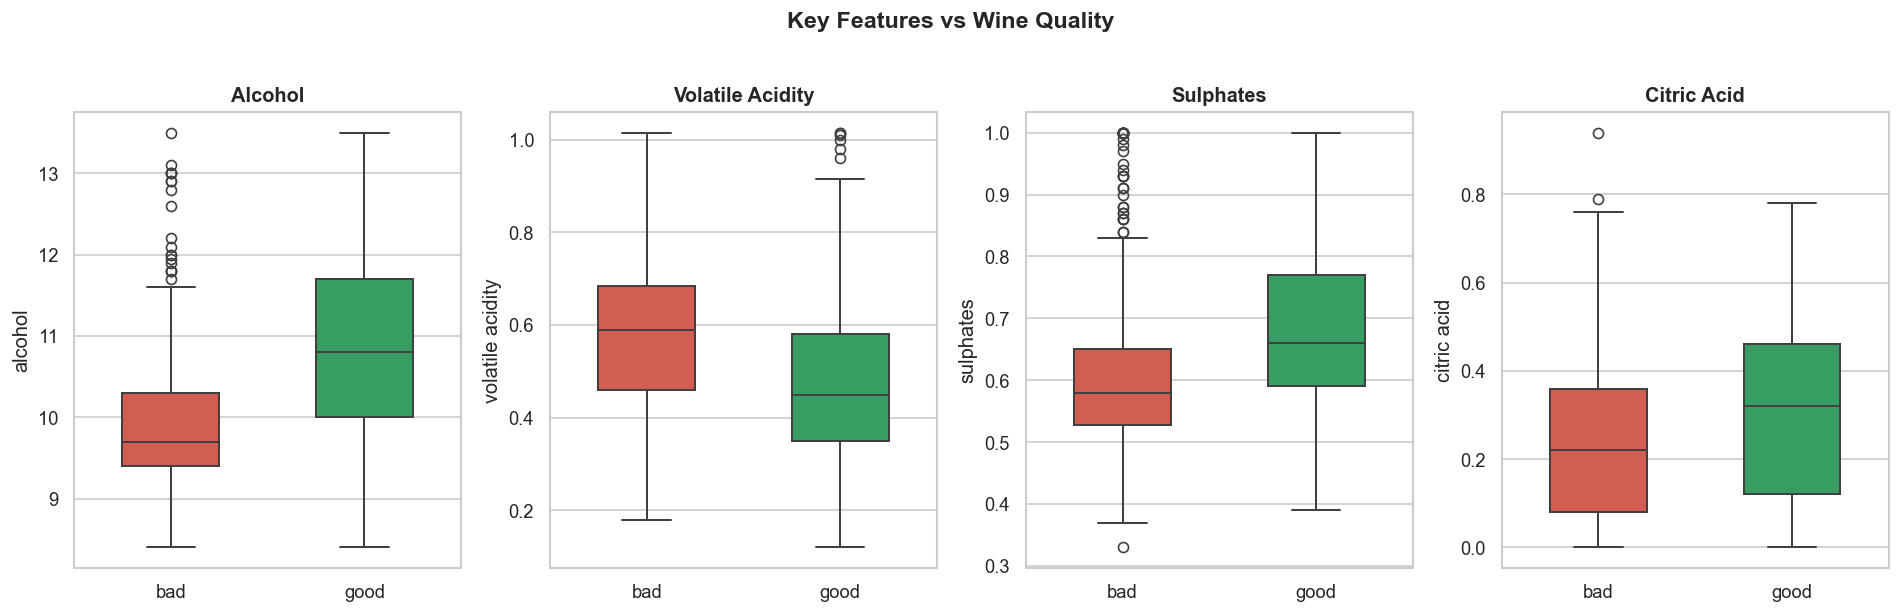

In [161]:
# Box plots — key features vs quality
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
palette = {'bad': '#E74C3C', 'good': '#27AE60'}

for ax, feat in zip(axes, key_features):
    sns.boxplot(data=df_clean, x='quality', y=feat, palette=palette, ax=ax,
                order=['bad', 'good'], width=0.5, linewidth=1.2)
    ax.set_title(feat.title(), fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Key Features vs Wine Quality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [167]:
# Elbow method — test K from 1 to 50 (odd values only to avoid ties)
k_range = range(1, 51, 2)
train_scores, test_scores, cv_scores = [], [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    train_scores.append(knn.score(x_train_scaled, y_train))
    test_scores.append(knn.score(x_test_scaled, y_test))
    cv = cross_val_score(knn, x_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

# Best K from CV
best_k = list(k_range)[np.argmax(cv_scores)]
print(f"Best K (by 5-fold CV accuracy): {best_k}")
print(f"CV Accuracy at K={best_k}: {max(cv_scores):.4f}")

Best K (by 5-fold CV accuracy): 39
CV Accuracy at K=39: 0.7433


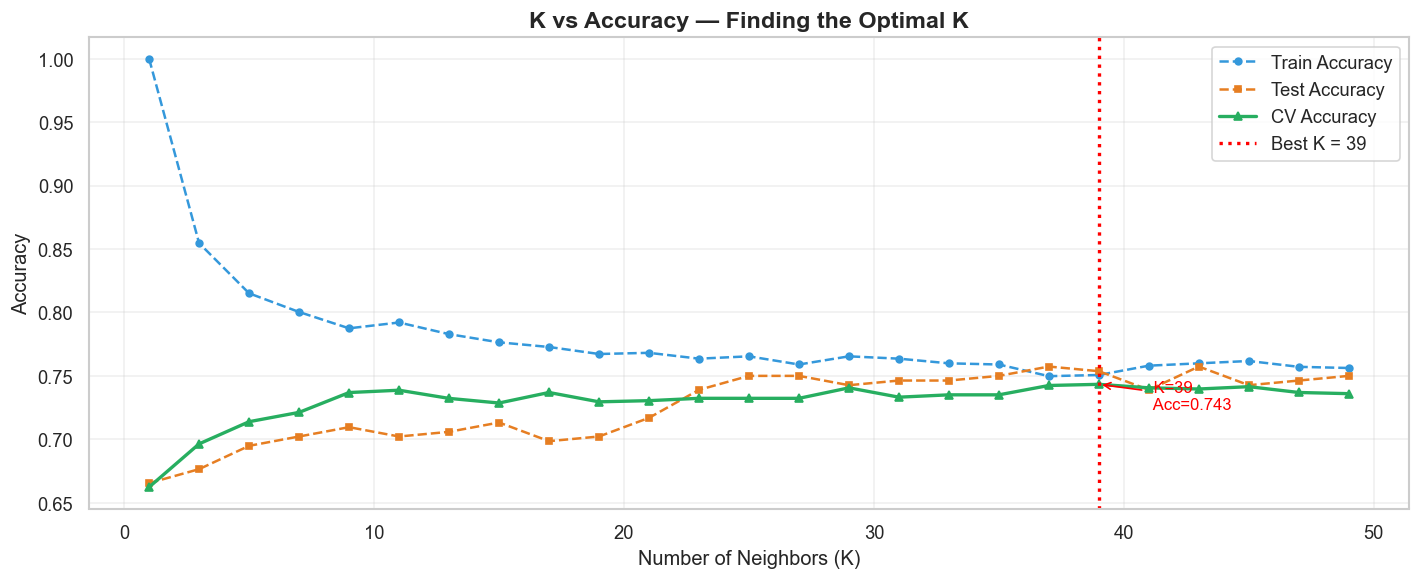

In [169]:
# Plot K vs Accuracy
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(list(k_range), train_scores, 'o--', color='#3498DB', label='Train Accuracy', linewidth=1.5, markersize=4)
ax.plot(list(k_range), test_scores,  's--', color='#E67E22', label='Test Accuracy',  linewidth=1.5, markersize=4)
ax.plot(list(k_range), cv_scores,    '^-',  color='#27AE60', label='CV Accuracy',    linewidth=2,   markersize=5)
ax.axvline(x=best_k, color='red', linestyle=':', linewidth=2, label=f'Best K = {best_k}')
ax.annotate(f' K={best_k}\n Acc={max(cv_scores):.3f}',
            xy=(best_k, max(cv_scores)), xytext=(best_k+2, max(cv_scores)-0.02),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('K vs Accuracy — Finding the Optimal K', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [171]:
# Train final model with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(x_train_scaled, y_train)

# Predictions
y_pred  = knn_final.predict(x_test_scaled)
y_proba = knn_final.predict_proba(x_test_scaled)[:, 1]

# Core metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print(f"  KNN Model (K={best_k}) — Test Results")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 50)

  KNN Model (K=39) — Test Results
  Accuracy  : 0.7537 (75.37%)
  ROC-AUC   : 0.8082


In [173]:
# Detailed classification report
print("\nCLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Bad       0.75      0.71      0.73       128
        Good       0.75      0.79      0.77       144

    accuracy                           0.75       272
   macro avg       0.75      0.75      0.75       272
weighted avg       0.75      0.75      0.75       272



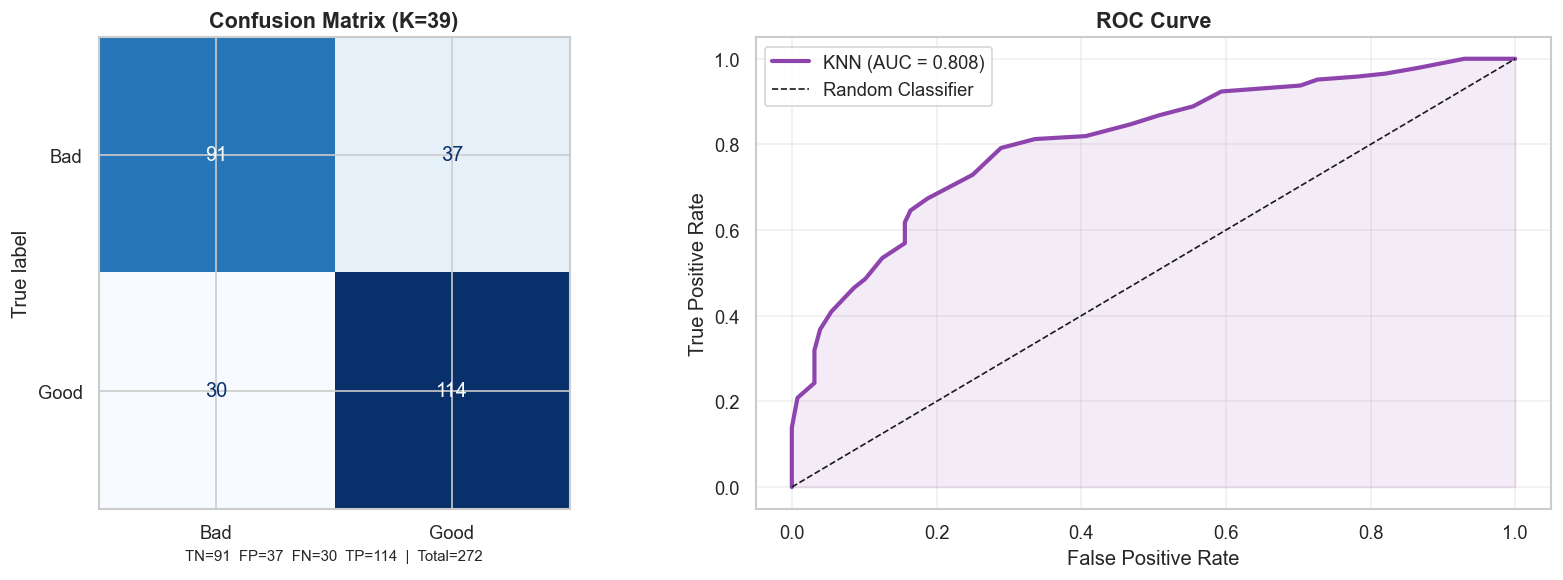

In [175]:
# Confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad', 'Good'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (K={best_k})', fontsize=13, fontweight='bold')

# Annotate with rates
total = cm.sum()
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}  |  Total={total}',
    fontsize=9
)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#8E44AD', linewidth=2.5, label=f'KNN (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#8E44AD')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [179]:
# Cross-validation scores (5-fold)
cv_results = cross_val_score(knn_final, 
                              scaler.fit_transform(x),  # use full dataset for CV
                              y, cv=5, scoring='accuracy')

print("5-FOLD CROSS VALIDATION RESULTS")
print("=" * 40)
for i, score in enumerate(cv_results, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  ─────────────────")
print(f"  Mean  : {cv_results.mean():.4f} ± {cv_results.std():.4f}")

5-FOLD CROSS VALIDATION RESULTS
  Fold 1: 0.7169
  Fold 2: 0.6912
  Fold 3: 0.7500
  Fold 4: 0.7500
  Fold 5: 0.7048
  ─────────────────
  Mean  : 0.7226 ± 0.0238


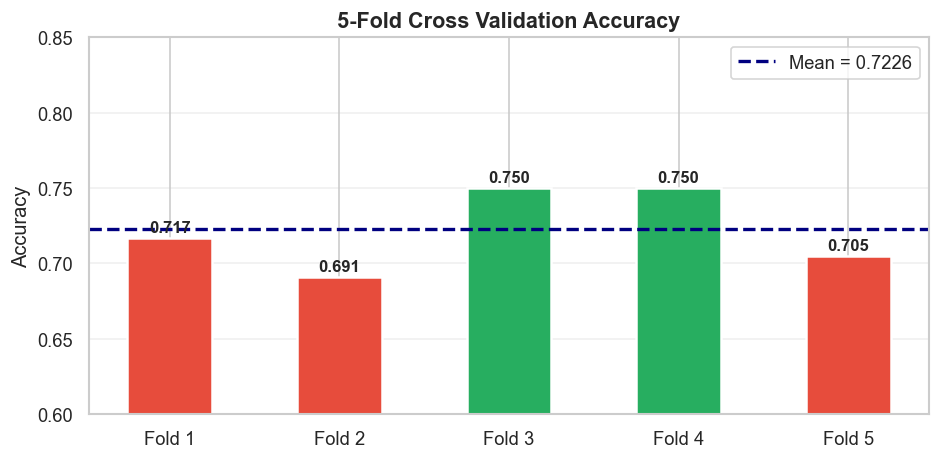

In [181]:
# Cross-validation bar chart
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i}' for i in range(1, 6)]
colors = ['#27AE60' if s >= cv_results.mean() else '#E74C3C' for s in cv_results]
bars = ax.bar(folds, cv_results, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.axhline(cv_results.mean(), color='navy', linestyle='--', linewidth=2, label=f'Mean = {cv_results.mean():.4f}')

for bar, val in zip(bars, cv_results):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.6, 0.85)
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross Validation Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

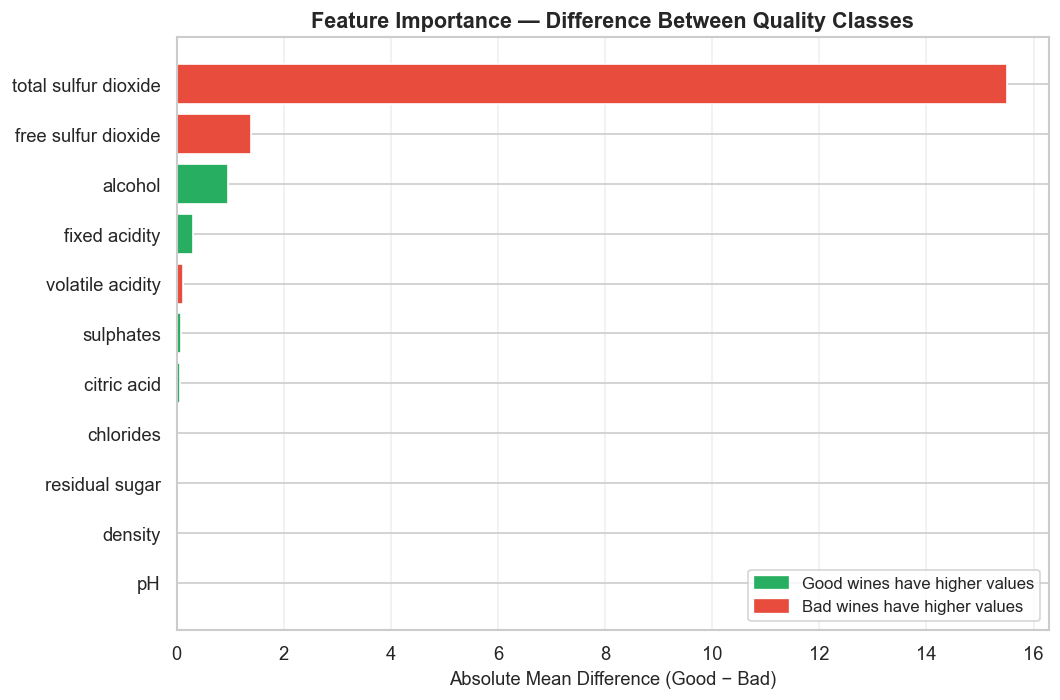


Top 3 features that most differentiate good from bad wines:
total sulfur dioxide    15.508366
free sulfur dioxide      1.381335
alcohol                  0.964230
dtype: float64


In [183]:
# Feature importance via permutation (mean absolute difference between classes)
feature_means = df_clean.groupby('quality')[features].mean()
feature_diff = (feature_means.loc['good'] - feature_means.loc['bad']).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#27AE60' if (feature_means.loc['good', f] > feature_means.loc['bad', f]) 
          else '#E74C3C' for f in feature_diff.index]
bars = ax.barh(feature_diff.index, feature_diff.values, color=colors, edgecolor='white', linewidth=1)

good_patch = mpatches.Patch(color='#27AE60', label='Good wines have higher values')
bad_patch  = mpatches.Patch(color='#E74C3C', label='Bad wines have higher values')
ax.legend(handles=[good_patch, bad_patch], fontsize=10, loc='lower right')

ax.set_xlabel('Absolute Mean Difference (Good − Bad)', fontsize=11)
ax.set_title('Feature Importance — Difference Between Quality Classes', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 features that most differentiate good from bad wines:")
print(feature_diff.sort_values(ascending=False).head(3))

In [185]:
# Summary metrics table
from sklearn.metrics import precision_score, recall_score, f1_score

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Good)', 'Recall (Good)', 'F1-Score (Good)', 'ROC-AUC', 'CV Mean Accuracy'],
    'Score': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(auc, 4),
        round(cv_results.mean(), 4)
    ]
})

summary['Interpretation'] = [
    'Overall correct predictions',
    'Of predicted "good", how many are actually good',
    'Of actual "good", how many were caught',
    'Harmonic mean of precision and recall',
    'Discriminative ability across all thresholds',
    'Robust estimate across 5 folds'
]

print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(summary.to_string(index=False))

MODEL PERFORMANCE SUMMARY
          Metric  Score                                  Interpretation
        Accuracy 0.7537                     Overall correct predictions
Precision (Good) 0.7550 Of predicted "good", how many are actually good
   Recall (Good) 0.7917          Of actual "good", how many were caught
 F1-Score (Good) 0.7729           Harmonic mean of precision and recall
         ROC-AUC 0.8082    Discriminative ability across all thresholds
CV Mean Accuracy 0.7226                  Robust estimate across 5 folds


In [187]:
# Mean feature values by quality class
print("MEAN CHEMICAL PROPERTIES BY QUALITY CLASS")
print("=" * 60)
comparison = df_clean.groupby('quality')[features].mean().round(3).T
comparison['Difference'] = (comparison['good'] - comparison['bad']).round(3)
comparison['Driver'] = comparison['Difference'].apply(lambda x: '↑ Good' if x > 0 else '↓ Bad')
print(comparison.sort_values('Difference', ascending=False))

MEAN CHEMICAL PROPERTIES BY QUALITY CLASS
quality                  bad    good  Difference  Driver
alcohol                9.919  10.883       0.964  ↑ Good
fixed acidity          8.118   8.432       0.314  ↑ Good
sulphates              0.609   0.687       0.078  ↑ Good
citric acid            0.237   0.303       0.066  ↑ Good
pH                     3.309   3.309       0.000   ↓ Bad
density                0.997   0.996      -0.001   ↓ Bad
residual sugar         2.327   2.321      -0.006   ↓ Bad
chlorides              0.085   0.078      -0.007   ↓ Bad
volatile acidity       0.590   0.473      -0.117   ↓ Bad
free sulfur dioxide   16.445  15.064      -1.381   ↓ Bad
total sulfur dioxide  54.298  38.789     -15.509   ↓ Bad


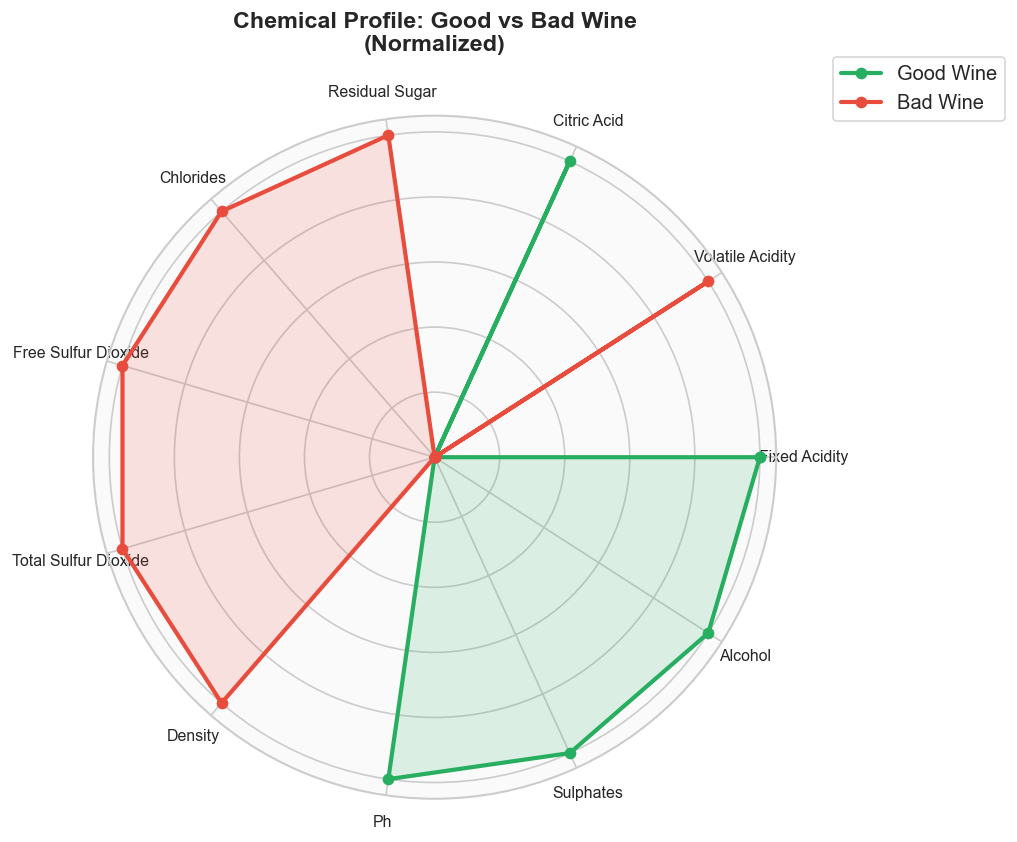

In [189]:
# Visual: Radar/spider chart comparing good vs bad wine profiles
from matplotlib.patches import FancyArrowPatch

# Normalize for radar
profile = df_clean.groupby('quality')[features].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

labels = features
N = len(labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor('#FAFAFA')

for quality, color, label in [('good', '#27AE60', 'Good Wine'), ('bad', '#E74C3C', 'Bad Wine')]:
    values = profile_norm.loc[quality].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=color, label=label)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.title() for f in labels], fontsize=9.5)
ax.set_yticklabels([])
ax.set_title('Chemical Profile: Good vs Bad Wine\n(Normalized)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=12)
plt.tight_layout()
plt.show()